# Course Project: Model Selection for Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In this course project, you will:

1. Load the Airbnb "listings" data set.
2. Train and test a logistic regression (LR) model using the scikit-learn default hyperparameter values.
2. Perform a grid search to identify the LR hyperparameter value that results in the best cross-validation score.
3. Fit the optimal model to the training data and make predictions on the test data.
4. Create a confusion matrix for both models.
5. Plot a precision-recall curve for both models.
6. Plot the ROC and compute the AUC for both models.

**<font color='red'>Note: Some of the code cells in this notebook may take a while to run.</font>**

## Part 1: Load the Data Set

We will work with a preprocessed version of the Airbnb NYC "listings" data set. 

<b>Task</b>: In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`.

You will be working with the file named "airbnb_readytofit.csv.gz" that is located in a folder named "data".

In [2]:
# YOUR CODE HERE
## Cell 01 -- runs without error

filename = os.path.join(os.getcwd(), "data", "airbnb_readytofit.csv.gz")
df = pd.read_csv(filename, header=0)

## Part 2: Create Training and Test Data Sets

### Create Labeled Examples 

<b>Task</b>: Create labeled examples from DataFrame `df`. 
In the code cell below, carry out the following steps:

* Get the `host_is_superhost` column from DataFrame `df` and assign it to the variable `y`. This will be our label.
* Get all other columns from DataFrame `df` and assign them to the variable `X`. These will be our features. 

First, we will store the label column as a separate object, called `y`, and consequently remove that column from the `X` feature set:

In [3]:
# YOUR CODE HERE
## Cell 02 -- runs without error

y = df['host_is_superhost']  ## label
X = df.drop(columns='host_is_superhost', axis=1)
X.head()

## Output: table, and 5 rows × 49 columns = counts table

,host_has_profile_pic,host_identity_verified,has_availability,instant_bookable,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,...,n_host_verifications,neighbourhood_group_cleansed_Bronx,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,True,True,True,False,-0.578829,-2.845589,-0.054298,-0.054298,-1.007673,-0.337606,...,1.888373,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,True,True,True,False,-4.685756,-0.430024,-0.112284,-0.112284,0.067470,-0.337606,...,0.409419,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,True,True,True,False,0.578052,-2.473964,-0.112284,-0.112284,0.605041,0.849692,...,-1.069535,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,True,False,True,False,0.578052,1.010024,-0.112284,-0.112284,-0.470102,-0.337606,...,-0.576550,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,True,True,True,False,-0.054002,-0.066308,-0.112284,-0.112284,-1.007673,-0.337606,...,0.902404,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Split Labeled Examples Into Training and Test Sets

<b>Task</b>: In the code cell below, create training and test sets out of the labeled examples. 

1. Use scikit-learn's `train_test_split()` function to create the data sets.

2. Specify:
    * A test set that is 10 percent of the size of the data set.
    * A seed value of '1234'. 
    


In [4]:
# YOUR CODE HERE
## Cell 03 -- runs without error looks correct

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10,random_state=1234)

In [5]:
X_train.head()

,host_has_profile_pic,host_identity_verified,has_availability,instant_bookable,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,...,n_host_verifications,neighbourhood_group_cleansed_Bronx,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
326,True,True,True,False,-0.868049,-2.706229,-0.120567,-0.120567,-0.470102,-0.337606,...,-0.083566,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
26890,True,False,True,False,0.578052,1.010024,-0.120567,-0.120567,0.605041,-0.337606,...,-1.562519,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
16767,True,True,True,False,0.578052,0.638399,-0.112284,-0.112284,-0.470102,-0.337606,...,1.395388,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
27743,True,True,True,True,0.288832,1.010024,-0.120567,-0.120567,2.755328,2.036990,...,-1.562519,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
9783,True,False,True,False,0.578052,1.010024,-0.104000,-0.104000,0.605041,-0.337606,...,-1.069535,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


## Part 3: Fit and Evaluate a Logistic Regression Model With Default Hyperparameter Values

<b>Task</b>: In the code cell below:

1. Using the scikit-learn `LogisticRegression` class, create a logistic regression model object with the following arguments: `max_iter=1000`. You will use the scikit-learn default value for hyperparameter $C$, which is 1.0. Assign the model object to the variable `model_default`.

2. Fit the model to the training data.

In [5]:
# 1. Create the  Scikit-learn LogisticRegression model object below and assign to variable 'model_default'
# YOUR CODE HERE
## Cell 04a -- correct runs without error
## Code notes: following lab 464 M1 06

model_default = LogisticRegression(C=1,max_iter=1000)

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 04b -- correct runs without error

model_default.fit(X_train,y_train)

LogisticRegression(C=1, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

<b>Task:</b> Test your model on the test set (`X_test`). 

1. Use the ``predict_proba()`` method  to use the fitted model to predict class probabilities for the test set. Note that the `predict_proba()` method returns two columns, one column per class label. The first column contains the probability that an unlabeled example belongs to class `False` (`host_is_superhost` is "False") and the second column contains the probability that an unlabeled example belongs to class `True` (`host_is_superhost` is "True"). Save the values of the *second* column to a list called ``proba_predictions_default``.

2. Use the ```predict()``` method to use the fitted model `model_default` to predict the class labels for the test set. Store the outcome in the variable ```class_label_predictions_default```. Note that the `predict()` method returns the class label (True or False) per unlabeled example.

In [6]:
# 1. Make predictions on the test data using the predict_proba() method
# YOUR CODE HERE
## Cell 05a -- drafted runs without error
## Cell notes: slicing because it's np, not iloc
probability_predictions = model_default.predict_proba(X_test)
proba_predictions_default_prep = probability_predictions[:, 1]
proba_predictions_default =  proba_predictions_default_prep.tolist()

## print(probability_predictions)
## print(proba_predictions_default_prep)
## print(proba_predictions_default)

# 2. Make predictions on the test data using the predict() method
# YOUR CODE HERE
## Cell 05b -- drafted runs without error

class_label_predictions_default = model_default.predict(X_test)


<b>Task</b>: Evaluate the accuracy of the model using a confusion matrix. In the cell below, create a confusion matrix out of `y_test` and `class_label_predictions_default`. Perform the following steps:

1. Call the `confusion_matrix()` function and save the resulting confusion matrix to the variable `c_m`. Call the function with the arguments: 
    1. `y_test`
    2. `class_label_predictions_default`
    3. The parameter `labels`. Assign the parameter a list containing two items: `True` and `False`. Note: these correspond to the two possible labels contained in `class_label_predictions_default`.

2. Use the Pandas `pd.DataFrame()` function to create a DataFrame out of the confusion matrix. Supply it the following arguments:
    1. The confusion matrix `c_m`
    2. The parameter `columns` with the value: `['Predicted: Host is not a super host', 'Predicted: Host is a super host']`
    3. The parameter `index` with the value: `['Actual: Host is not a super host', 'Actual: Host is a super host']`

In [7]:
# Create a confusion matrix
# YOUR CODE HERE
# Cell 06a -- drafted ran without error
## Code source notes: Lab 465 M4 05 Confusion Matrix Demo

c_m = confusion_matrix(y_test, class_label_predictions_default, labels=[True, False])

# Create a Pandas DataFrame out of the confusion matrix for display
# YOUR CODE HERE
## Cell 06b -- drafted ran without error
pd.DataFrame(c_m, columns=['Predicted: Host is not a super host', 'Predicted: Host is a super host'], index = ['Actual: Host is not a super host', 'Actual: Host is a super host'])


,Predicted: Host is not a super host,Predicted: Host is a super host
Actual: Host is not a super host,265,450
Actual: Host is a super host,91,1997


## Part 4: Perform Logistic Regression Model Selection Using `GridSearchSV`

Our goal is to find the optimal choice of hyperparameter $C$. 

### Set Up a Parameter Grid 

The code cell below creates a dictionary called `param_grid` with:
* a key called 'C' 
* a value which is a list consisting of 10 values for the hyperparameter $C$

It uses a scikit-learn function `11_min_c()` to assist in the creation of possible values for $C$. For more information, consult the online [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.l1_min_c.html).

In [8]:
from sklearn.svm import l1_min_c

cs = l1_min_c(X_train, y_train, loss="log") * np.logspace(0, 7, 16)
param_grid = dict(C = list(cs))
param_grid

{'C': [0.0001537633581917429,
  0.0004503182232067712,
  0.0013188220167462046,
  0.0038623609310518637,
  0.011311482347345912,
  0.03312731129440893,
  0.09701812016301883,
  0.28413159028558327,
  0.8321204375281983,
  2.436984996480532,
  7.137062864015964,
  20.901920364088983,
  61.214295464518635,
  179.2749136895258,
  525.0325015504883,
  1537.633581917429]}

### Perform Grid Search Cross-Validation

<b>Task:</b> Use `GridSearchCV` to search over the different values of hyperparameter $C$ to find the one that results in the best cross-validation (CV) score.

Complete the code in the cell below.

In [10]:
print('Running Grid Search...')

# 1. Create a LogisticRegression model object with the argument max_iter=1000. 
#    Save the model object to the variable 'model'
# YOUR CODE HERE
## Cell 07a -- runs without error

model = LogisticRegression(C=1,max_iter=1000)

# 2. Run a grid search with 5-fold cross-validation and assign the output to the 
# object 'grid'.
# YOUR CODE HERE
## Cell 07b -- runs without error
## Code Source notes: Lab M3 04 Feature Selection...param_grid from step above

grid = GridSearchCV(model,param_grid,cv=5)

# 3. Fit the model on the training data and assign the fitted model to the 
#    variable 'grid_search'
# YOUR CODE HERE
## Cell 07c -- runs without error

grid_search = grid.fit(X_train, y_train)

print('Done')

print(grid_search)

Running Grid Search...
Done
GridSearchCV(cv=5, error_score=nan,
             estimator=LogisticRegression(C=1, class_weight=None, dual=False,
                                          fit_intercept=True,
                                          intercept_scaling=1, l1_ratio=None,
                                          max_iter=1000, multi_class='auto',
                                          n_jobs=None, penalty='l2',
                                          random_state=None, solver='lbfgs',
                                          tol=0.0001, verbose=0,
                                          warm_start=False),
             iid='deprecated', n_jobs=None,
             param_grid={'C': [0.0001537633581917429, 0.0...
                               0.0013188220167462046, 0.0038623609310518637,
                               0.011311482347345912, 0.03312731129440893,
                               0.09701812016301883, 0.28413159028558327,
                               0.8321204

<b>Task</b>: Retrieve the value of the hyperparameter $C$ for which the best score was attained. Save the result to the variable `best_c`.

In [15]:
# YOUR CODE HERE
## Cell 08 -- runs without error
#it says best_c but then code here says best_C so I went with code here for consistency
# 2nd day working on this project and ran thru code again, noticed that this was just pulling best score which was not correct
## then fixed that but was pulling the full tuple instead of one value. Now looks good.

best_C = grid_search.best_params_['C']

best_C

## Output: 0.8078829992280504 
## QC I can see that value on the param_grid variable printout

525.0325015504883

## Part 5: Fit and Evaluate the Optimal Logistic Regression Model 

<b>Task</b>: Initialize a `LogisticRegression` model object with the best value of hyperparameter `C` model and fit the model to the training data. The model object should be named `model_best`. Note: Supply `max_iter=1000` as an argument when creating the model object.

In [16]:
# 1. Create the  model object below and assign to variable 'model_best'
# YOUR CODE HERE
## Cell 09a -- runs without error

model_best = LogisticRegression(C=best_C,max_iter=1000)

# 2. Fit the model to the training data below
# YOUR CODE HERE
## Cell 09b -- runs without error

model_best.fit(X_train,y_train)

LogisticRegression(C=525.0325015504883, class_weight=None, dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

<b>Task:</b> Test your model on the test set (`X_test`).

1. Use the ``predict_proba()`` method  to use the fitted model `model_best` to predict class probabilities for the test set. Save the values of the *second* column to a list called ``proba_predictions_best``.

2. Use the ```predict()``` method to use the fitted model `model_best` to predict the class labels for the test set. Store the outcome in the variable ```class_label_predictions_best```. 

In [22]:
# 1. Make predictions on the test data using the predict_proba() method
# YOUR CODE HERE
## Cell 10a -- ran without errors # ah crap it wasn't pulling only 2nd column so got errors later on, fixing
proba_predictions_best_array = model_best.predict_proba(X_test)
proba_predictions_best = proba_predictions_best_array[:, 1]


# 2. Make predictions on the test data using the predict() method
# YOUR CODE HERE
## Cell 10b -- ran without errors

class_label_predictions_best = model_best.predict(X_test)

<b>Task</b>: Evaluate the accuracy of the model using a confusion matrix. In the cell below, create a confusion matrix out of `y_test` and `class_label_predictions_best`.

In [23]:
# YOUR CODE HERE
## Cell 11 -- runs without errors
## Results are an improvement on the model from previous confusion matrix 
## (not not went from 265 to 270, is is went from 1997 to 2000)

c_m_best = confusion_matrix(y_test, class_label_predictions_best, labels=[True, False])

pd.DataFrame(c_m_best, columns=['Predicted: Host is not a super host', 'Predicted: Host is a super host'], index = ['Actual: Host is not a super host', 'Actual: Host is a super host'])


,Predicted: Host is not a super host,Predicted: Host is a super host
Actual: Host is not a super host,270,445
Actual: Host is a super host,88,2000


## Part 6:  Plot Precision-Recall Curves for Both Models

Recall that scikit-learn defaults to a 0.5 classification threshold. Sometimes we may want a different threshold. 

The precision-recall curve shows the trade-off between precision and recall for different classification thresholds. Scikit-learn's `precision_recall_curve()` function computes precision-recall pairs for different probability thresholds. For more information, consult the [Scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html).

Let's first import the function.

In [19]:
from sklearn.metrics import precision_recall_curve

<b>Task:</b> In the code cell below, use `precision_recall_curve()` to compute precision-recall pairs for both models.

For `model_default`:
* call `precision_recall_curve()` with `y_test` and `proba_predictions_default`
* the function returns three outputs. Save the three outputs to the variables `precision`, `recall`, and `thresholds`, respectively. 

For `model_best`:
* call `precision_recall_curve()` with `y_test` and `proba_predictions_best`
* save the output to the variables `precision_best`, `recall_best` and `thresholds_best`, respectively


In [24]:
## Cell 12a -- runs without error
## coding fixing notes: y_score is not the right shape? crap - now runs without error
precision_default, recall_default, thresholds_default = precision_recall_curve(y_test,proba_predictions_default) 

## Cell 12b -- working -- not right order wn function
precision_best, recall_best, thresholds_best = precision_recall_curve(y_test,proba_predictions_best) 

The code cell below uses seaborn's `lineplot()` function to visualize the precision-recall curve for both models. 
"Recall" will be on the $x$-axis and "Precision" will be on the $y$-axis. The plot for "default" will be green. The plot for the "best" will be red.


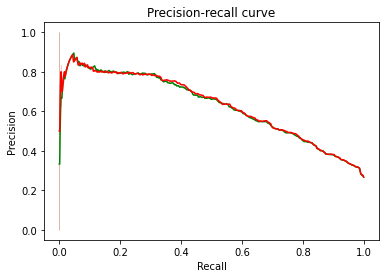

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

sns.lineplot(x=recall_default, y=precision_default, color='g')
sns.lineplot(x=recall_best, y=precision_best, color='r')


plt.title("Precision-recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Part 7: Plot ROC Curves and Compute the AUC for Both Models

You will next use scikit-learn's `roc_curve()` function to plot the receiver operating characteristic (ROC) curve and the `auc()` function to compute the area under the curve (AUC) for both models.

* An ROC curve plots the performance of a binary classifier for varying classification thresholds. It plots the fraction of true positives out of the positives vs. the fraction of false positives out of the negatives. For more information on how to use the `roc_curve()` function, consult the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html).

* The AUC measures the trade-off between the true positive rate and false positive rate. It provides a broad view of the performance of a classifier since it evaluates the performance for all the possible threshold values; it essentially provides a value that summarizes the the ROC curve. For more information on how to use the `auc()` function, consult the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html).

Let's first import the functions.

In [27]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

<b>Task:</b> Using the `roc_curve()` function, record the true positive and false positive rates for both models. 

1. Call `roc_curve()` with arguments `y_test` and `proba_predictions_default`. The `roc_curve` function produces three outputs. Save the three items to the following variables, respectively: `fpr_default` (standing for 'false positive rate'),  `tpr_default` (standing for 'true positive rate'), and `thresholds_default`.

2. Call `roc_curve()` with arguments `y_test` and `proba_predictions_best`. The `roc_curve` function produces three outputs. Save the three items to the following variables, respectively: `fpr_best` (standing for 'false positive rate'),  `tpr_best` (standing for 'true positive rate'), and `thresholds_best`.

In [28]:
fpr_default, tpr_default, thresholds_default = roc_curve(y_test,proba_predictions_default)  ## Cell 13a 
fpr_best, tpr_best, thresholds_best = roc_curve(y_test,proba_predictions_best) ## Cell 13b

<b>Task</b>: Create <b>two</b> `seaborn` lineplots to visualize the ROC curve for both models. 

The plot for the default hyperparameter should be green. The plot for the best hyperparameter should be red.

* In each plot, the `fpr` values should be on the $x$-axis.
* In each plot, the`tpr` values should be on the $y$-axis. 
* In each plot, label the $x$-axis "False positive rate".
* In each plot, label the $y$-axis "True positive rate".
* Give each plot the title "Receiver operating characteristic (ROC) curve".
* Create a legend on each plot indicating that the plot represents either the default hyperparameter value or the best hyperparameter value.

<b>Note:</b> It may take a few minutes to produce each plot.

#### Plot ROC Curve for Default Hyperparameter:

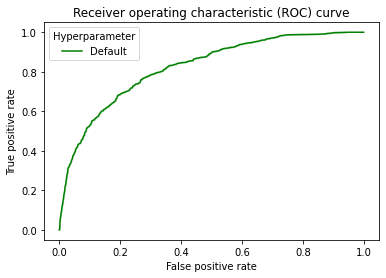

In [39]:
# YOUR CODE HERE
## Cell 14 -- runs without error, looks correct
## code notes: needed to infer specific variable names based on previous cells not instructions


fig = plt.figure()
ax = fig.add_subplot()

sns.lineplot(x=fpr_default, y= tpr_default, color='g', label="Default")


plt.title("Receiver operating characteristic (ROC) curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(title="Hyperparameter")
plt.show()

#### Plot ROC Curve for Best Hyperparameter:

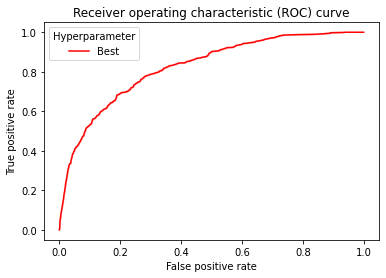

In [40]:
# YOUR CODE HERE
## Cell 15 -- runs without error, looks correct... 

fig = plt.figure()
ax = fig.add_subplot(111)

sns.lineplot(x=fpr_best, y= tpr_best, color='r',label="Best")


plt.title("Receiver operating characteristic (ROC) curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(title="Hyperparameter")
plt.show()

<b>Task</b>: Use the `auc()` function to compute the area under the receiver operating characteristic (ROC) curve for both models.

For each model, call the function with the `fpr` argument first and the `tpr` argument second. 

Save the result of the `auc()` function for `model_default` to the variable `auc_default`.
Save the result of the `auc()` function for `model_best` to the variable `auc_best`. 
Compare the results.

In [31]:
# YOUR CODE HERE
## Cell 16 -- runs without error, makes sense
## code source notes https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html
## infering that "model_default" in instructions means use x = fpr_default and y = tpr_default, from code above


auc_default = auc(fpr_default,tpr_default)

auc_best = auc(fpr_best,tpr_best)


print(auc_default)
print(auc_best)

## Output:
## 0.8227761701899632
## 0.8242651984031294



0.8227761701899632
0.8242651984031294


0.0014890282131662103


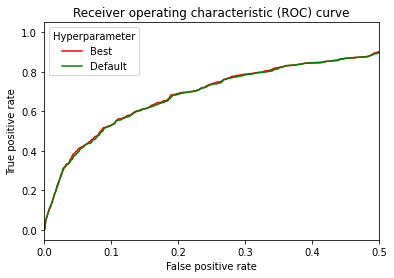

In [37]:
## Comparing results:
## model_default's auc = 0.8227761701899632
## model_best's    auc = 0.8242651984031294


print(auc_best-auc_default)

## Output: 0.0014890282131662103

# Comparing results:
# model_best has a higher (closer to 1) auc value than model_default, by 0.001489 area under the curve 
## Therefore, model_best performed better than model_default.


# showing both ROC together and zoomed into smaller x axis values to highlight differences btwn lines
fig = plt.figure()
ax = fig.add_subplot(111)

sns.lineplot(x=fpr_best, y= tpr_best, color='r',label="Best")
sns.lineplot(x=fpr_default, y= tpr_default, color='g', label="Default")

ax.set_xlim(0,0.5)

plt.title("Receiver operating characteristic (ROC) curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(title="Hyperparameter")
plt.show()
